# Supplementary Figure S6: Boundary Mutual Information

Supplementary Figure S6 studies mutual information between two boundary intervals in the undecorated MERA and regular hyperbolic graph states.

This figure includes:

* (a) MERA mutual information versus separation distance
* (b) regular hyperbolic $\{3,7\}$ mutual information versus separation distance
* (c) MERA mutual information versus circular cross-ratio $\eta$
* (d) regular hyperbolic $\{3,7\}$ mutual information versus circular cross-ratio $\eta$

## Import Dependencies and Set Parameters

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import os
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "global_figure_settings.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

from __future__ import annotations

import hashlib
import json
import os
import pickle
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path("outputs/mplconfig").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import importlib
import mpmath as mp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import Bbox
from tqdm.auto import tqdm

import loadconfig as loco
from graph2grav import gaussian
from graph2grav.analysis import Analysis
from graph2grav.figure_hashing import save_figure_with_hash
import graph2grav.tree_wormhole_knockout as twk

importlib.reload(twk)
TreeWormholeConfig = twk.TreeWormholeConfig
build_graph = twk.build_graph
boundary_after_measurement_payload = twk.boundary_after_measurement_payload
domain_boundary_nodes = twk.domain_boundary_nodes

config = loco.reload()
plt.rcParams.update({"figure.dpi": 120})
subfigure_label_fontsize = config["subfigure-label"]["font"]["size"]

COLORS = {
    "mera": config["graph"]["nodes"]["ancilla"]["outer"]["color"],
    "hyperbolic": config["graph"]["nodes"]["boundary"]["outer"]["color"],
    "fit": "#111827",
    "grid": "#cbd5e1",
}
PAIR_COLORS = ["#2563a8", "#2ca02c", "#b45309", "#7c3aed"]

FIGURE_PATH = Path("figures/supplementary-figure_boundary-mutual-information.pdf")
CACHE_DIR = Path("outputs/notebook_cache/S08_boundary_mutual_information")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

couplingtime = 1.0
presqueeze = 0.1
interval_pairs = [(2, 2), (4, 4), (8, 8), (16, 16)]
small_x_fit_factor = 4.0
small_x_fit_min_points = 5
cft_subtraction_dps = 80
use_notebook_cache = True
clear_notebook_cache = False
notebook_cache_version = 5

mera_config = TreeWormholeConfig(
    graph_kind="mera",
    mera_depth=7,
    use_decorated=False,
    couplingtime=couplingtime,
    presqueeze=presqueeze,
)
hyperbolic_config = TreeWormholeConfig(
    graph_kind="hyperbolic",
    hyperbolic_p=3,
    hyperbolic_q=7,
    hyperbolic_depth=4,
    hyperbolic_boundary_shells=1,
    use_decorated=False,
    couplingtime=couplingtime,
    presqueeze=presqueeze,
)




## Define Cache Helpers

Construct stable cache keys for the two-interval calculations.

In [2]:
def config_cache_dict(config):
    return {key: value for key, value in vars(config).items() if not key.startswith("_")}


def notebook_cache_path(cache_kind, *, config, l1=None, l2=None, renyi2=False):
    cache_key = {
        "cache_version": notebook_cache_version,
        "cache_kind": cache_kind,
        "config": config_cache_dict(config),
        "l1": None if l1 is None else int(l1),
        "l2": None if l2 is None else int(l2),
        "renyi2": bool(renyi2),
    }
    digest = hashlib.sha256(json.dumps(cache_key, sort_keys=True).encode("utf-8")).hexdigest()[:16]
    return CACHE_DIR / f"{cache_kind}_{digest}.pkl"


def maybe_clear_cache_path(cache_path):
    if clear_notebook_cache and cache_path.exists():
        cache_path.unlink()


def save_cached_result(cache_path, result):
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    with cache_path.open("wb") as handle:
        pickle.dump({"cache_version": notebook_cache_version, "result": result}, handle)


def load_cached_result(cache_path):
    with cache_path.open("rb") as handle:
        payload = pickle.load(handle)
    if payload.get("cache_version") != notebook_cache_version:
        return None
    return payload.get("result")


def periodic_interval_positions(start, length, boundary_count):
    return [int((int(start) + offset) % int(boundary_count)) for offset in range(int(length))]


def two_interval_positions(boundary_count, l1, l2, gap, start=0):
    first = periodic_interval_positions(start, l1, boundary_count)
    second_start = int(start) + int(l1) + int(gap)
    second = periodic_interval_positions(second_start, l2, boundary_count)
    return first + second


def entropy_for_boundary_positions(payload, positions, *, renyi2=False):
    kept_positions = [int(position) for position in positions if int(position) in payload["boundary_nodes_map"]]
    return float(
        gaussian.calculate_boundary_entropy(
            gaussian.to_inter(payload["boundary_after"]),
            kept_positions,
            payload["boundary_nodes_map"],
            renyi=bool(renyi2),
            alpha=2,
        )
    )


def chord_distance(boundary_count, x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return (float(boundary_count) / np.pi) * np.abs(np.sin(np.pi * (x - y) / float(boundary_count)))


def chord_distance_mp(boundary_count, x, y):
    boundary_count = mp.mpf(int(boundary_count))
    return (boundary_count / mp.pi) * abs(mp.sin(mp.pi * (mp.mpf(int(x)) - mp.mpf(int(y))) / boundary_count))


def two_interval_geometry_mp(boundary_count, l1, l2, gaps, *, fixed_c=None, dps=80):
    cross_ratio = []
    universal_mi_piece = []
    with mp.workdps(int(dps)):
        for gap in gaps:
            gap = int(gap)
            u1 = 0
            v1 = int(l1)
            u2 = int(l1) + gap
            v2 = int(l1) + int(l2) + gap
            d_u1_v1 = chord_distance_mp(boundary_count, u1, v1)
            d_u2_v2 = chord_distance_mp(boundary_count, u2, v2)
            d_u1_u2 = chord_distance_mp(boundary_count, u1, u2)
            d_v1_v2 = chord_distance_mp(boundary_count, v1, v2)
            x_mp = (d_u1_v1 * d_u2_v2) / (d_u1_u2 * d_v1_v2)
            cross_ratio.append(float(x_mp))
            if fixed_c is None or x_mp <= 0 or x_mp >= 1:
                universal_mi_piece.append(np.nan)
            else:
                universal = -(mp.mpf(str(fixed_c)) / 3) * mp.log1p(-x_mp)
                universal_mi_piece.append(float(universal))
    result = {"cross_ratio": np.asarray(cross_ratio, dtype=float)}
    if fixed_c is not None:
        result["universal_mi_piece"] = np.asarray(universal_mi_piece, dtype=float)
    return result


def two_interval_geometry(boundary_count, l1, l2, gaps):
    gaps = np.asarray(gaps, dtype=float)
    u1 = np.zeros_like(gaps)
    v1 = np.full_like(gaps, float(l1))
    u2 = float(l1) + gaps
    v2 = float(l1 + l2) + gaps
    wrap_gap = float(boundary_count) - v2
    high_precision = two_interval_geometry_mp(boundary_count, l1, l2, gaps, dps=cft_subtraction_dps)
    return {"wrap_gap": wrap_gap, "cross_ratio": high_precision["cross_ratio"]}


def universal_mi_piece_from_geometry(boundary_count, l1, l2, gaps, *, fixed_c):
    return two_interval_geometry_mp(
        boundary_count,
        l1,
        l2,
        gaps,
        fixed_c=fixed_c,
        dps=cft_subtraction_dps,
    )["universal_mi_piece"]



## Fit Single-Interval Entropy

Extract the CFT entropy fit used to set the reference scale for the mutual-information analysis.

In [3]:
def fit_single_interval_central_charge(config):
    graph = build_graph(config)
    analysis = Analysis(
        graph,
        couplingtime=float(config.couplingtime),
        global_presqueeze=float(config.presqueeze),
        is_decorated=bool(config.use_decorated),
    )
    central_charge, offset = analysis.fit_central_charge()
    return {
        "central_charge": float(central_charge),
        "offset": float(offset),
        "central_charge_stderr": float(analysis.central_charge_stderr),
        "offset_stderr": float(analysis.cft_entropy_offset_stderr),
        "boundary_length": int(analysis.boundary_length),
    }


def cached_fit_single_interval_central_charge(config):
    cache_path = notebook_cache_path("single_interval_fit", config=config)
    maybe_clear_cache_path(cache_path)
    if use_notebook_cache and cache_path.exists():
        cached = load_cached_result(cache_path)
        if cached is not None:
            tqdm.write(f"Loaded single-interval fit cache: {cache_path.name}")
            return cached
    result = fit_single_interval_central_charge(config)
    if use_notebook_cache:
        save_cached_result(cache_path, result)
        tqdm.write(f"Saved single-interval fit cache: {cache_path.name}")
    return result


def sweep_two_interval_gap(config, l1, l2, *, renyi2=False):
    graph = build_graph(config)
    payload = boundary_after_measurement_payload(
        graph,
        couplingtime=float(config.couplingtime),
        presqueeze=float(config.presqueeze),
    )
    boundary_count = len(domain_boundary_nodes(graph))
    max_gap = boundary_count - int(l1) - int(l2)
    if max_gap < 0:
        raise ValueError(f"Interval lengths ({l1}, {l2}) are too large for boundary count {boundary_count}.")

    gaps = np.arange(max_gap + 1, dtype=int)
    union_entropies = np.asarray(
        [
            entropy_for_boundary_positions(
                payload,
                two_interval_positions(boundary_count, l1, l2, int(gap)),
                renyi2=bool(renyi2),
            )
            for gap in tqdm(gaps, desc=f"{config.graph_kind} union ({l1}, {l2})", leave=False)
        ],
        dtype=float,
    )
    s_a1 = entropy_for_boundary_positions(
        payload,
        periodic_interval_positions(0, int(l1), boundary_count),
        renyi2=bool(renyi2),
    )
    s_a2 = np.asarray(
        [
            entropy_for_boundary_positions(
                payload,
                periodic_interval_positions(int(l1) + int(gap), int(l2), boundary_count),
                renyi2=bool(renyi2),
            )
            for gap in tqdm(gaps, desc=f"{config.graph_kind} single A2 ({l1}, {l2})", leave=False)
        ],
        dtype=float,
    )
    return {
        "graph": graph,
        "payload": payload,
        "boundary_count": int(boundary_count),
        "l1": int(l1),
        "l2": int(l2),
        "gaps": gaps,
        "union_entropies": union_entropies,
        "s_a1": float(s_a1),
        "s_a2": s_a2,
        "mutual_information": float(s_a1) + s_a2 - union_entropies,
    }


def cached_sweep_two_interval_gap(config, l1, l2, *, renyi2=False):
    cache_path = notebook_cache_path("two_interval_gap_sweep", config=config, l1=l1, l2=l2, renyi2=renyi2)
    maybe_clear_cache_path(cache_path)
    if use_notebook_cache and cache_path.exists():
        cached = load_cached_result(cache_path)
        if cached is not None:
            tqdm.write(f"Loaded two-interval sweep cache: {cache_path.name}")
            return cached
    result = sweep_two_interval_gap(config, l1, l2, renyi2=renyi2)
    if use_notebook_cache:
        save_cached_result(cache_path, result)
        tqdm.write(f"Saved two-interval sweep cache: {cache_path.name}")
    return result


## Define Mutual-Information Helpers

Compute two-interval geometry, cross-ratio data, and optional diagnostics.

In [4]:
def extract_g_from_mutual_information(results, *, fixed_c):
    geometry = two_interval_geometry(results["boundary_count"], results["l1"], results["l2"], results["gaps"])
    gaps = np.asarray(results["gaps"], dtype=int)
    wrap_gap = np.asarray(geometry["wrap_gap"], dtype=float)
    cross_ratio = np.asarray(geometry["cross_ratio"], dtype=float)
    mutual_information = np.asarray(results["mutual_information"], dtype=float)
    mask = (gaps > 0) & (wrap_gap > 0) & np.isfinite(cross_ratio) & (cross_ratio > 0.0) & (cross_ratio < 1.0)
    universal_mi_piece = universal_mi_piece_from_geometry(
        results["boundary_count"],
        results["l1"],
        results["l2"],
        results["gaps"],
        fixed_c=fixed_c,
    )
    g_curve = universal_mi_piece - mutual_information
    g_curve[~mask] = np.nan
    enriched = dict(results)
    enriched["geometry"] = geometry
    enriched["fixed_c"] = float(fixed_c)
    enriched["g_curve"] = g_curve
    enriched["mask"] = mask
    enriched["universal_mi_piece"] = universal_mi_piece
    return enriched


def fit_small_x_power_law(series, *, x_factor=4.0, min_points=5):
    x_parts = []
    i_parts = []
    for entry in series:
        x = np.asarray(entry["geometry"]["cross_ratio"], dtype=float)
        mi = np.asarray(entry["mutual_information"], dtype=float)
        mask = np.asarray(entry["mask"], dtype=bool)
        base_valid = mask & np.isfinite(x) & np.isfinite(mi) & (x > 0.0) & (mi > 0.0)
        if not np.any(base_valid):
            continue
        x_min = float(np.min(x[base_valid]))
        valid = base_valid & (x <= x_min * float(x_factor))
        if np.any(valid):
            x_parts.append(x[valid])
            i_parts.append(mi[valid])

    if not x_parts:
        return {"num_points": 0, "slope_p": np.nan, "delta_min": np.nan, "x_fit": np.asarray([]), "i_fit": np.asarray([])}

    x_data = np.concatenate(x_parts)
    i_data = np.concatenate(i_parts)
    order = np.argsort(x_data)
    x_data = x_data[order]
    i_data = i_data[order]
    if x_data.size < int(min_points):
        return {"num_points": int(x_data.size), "slope_p": np.nan, "delta_min": np.nan, "x_fit": np.asarray([]), "i_fit": np.asarray([])}

    slope_p, intercept_log_c = np.polyfit(np.log(x_data), np.log(i_data), 1)
    x_fit = np.geomspace(float(np.min(x_data)), float(np.max(x_data)), 200)
    i_fit = np.exp(intercept_log_c) * (x_fit ** slope_p)
    return {
        "num_points": int(x_data.size),
        "slope_p": float(slope_p),
        "delta_min": float(slope_p / 2.0),
        "x_fit": x_fit,
        "i_fit": i_fit,
    }


def analyze_system(label, config):
    fit = cached_fit_single_interval_central_charge(config)
    series = []
    for l1, l2 in tqdm(interval_pairs, desc=f"{label} interval pairs", leave=False):
        sweep = cached_sweep_two_interval_gap(config, l1, l2)
        entry = extract_g_from_mutual_information(sweep, fixed_c=fit["central_charge"])
        entry["small_x_fit"] = fit_small_x_power_law([entry], x_factor=small_x_fit_factor, min_points=small_x_fit_min_points)
        series.append(entry)
    return {
        "label": label,
        "config": config,
        "single_interval_fit": fit,
        "series": series,
        "small_x_fit": fit_small_x_power_law(series, x_factor=small_x_fit_factor, min_points=small_x_fit_min_points),
    }


systems = [
    analyze_system("Periodic MERA", mera_config),
    analyze_system(r"Hyperbolic $\{3,7\}$", hyperbolic_config),
]

for system in systems:
    fit = system["single_interval_fit"]
    print(
        f"{system['label']}: L = {fit['boundary_length']}, "
        f"c = {fit['central_charge']:.4f} +/- {fit['central_charge_stderr']:.4f}"
    )



Loaded single-interval fit cache: single_interval_fit_a72ffb266e2a09eb.pkl


Periodic MERA interval pairs:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded two-interval sweep cache: two_interval_gap_sweep_c7e91c6b7c4894b1.pkl
Loaded two-interval sweep cache: two_interval_gap_sweep_d53e8d89771ff928.pkl
Loaded two-interval sweep cache: two_interval_gap_sweep_351ea54082580b65.pkl
Loaded two-interval sweep cache: two_interval_gap_sweep_940455a97f9f7540.pkl
Loaded single-interval fit cache: single_interval_fit_17c2f6adefe55121.pkl


Hyperbolic $\{3,7\}$ interval pairs:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded two-interval sweep cache: two_interval_gap_sweep_e41fc90360640fcd.pkl
Loaded two-interval sweep cache: two_interval_gap_sweep_9c7dd3a2fd668ddc.pkl
Loaded two-interval sweep cache: two_interval_gap_sweep_b305a30203c8f7a8.pkl
Loaded two-interval sweep cache: two_interval_gap_sweep_8680193c6a104077.pkl
Periodic MERA: L = 128, c = 7.8183 +/- 0.1232
Hyperbolic $\{3,7\}$: L = 147, c = 10.0531 +/- 0.1402


## Make Figure

Assemble the two-by-two mutual-information figure and save the supplementary output.

Saved figure to figures/supplementary-figure_boundary-mutual-information.pdf. Hash info updated in figures/.hashes.json; history in figures/.hash_history.json. file_hash=9afcafe0e7f2349f, data_hash=cfcc3f3579304222, size=55096 bytes.


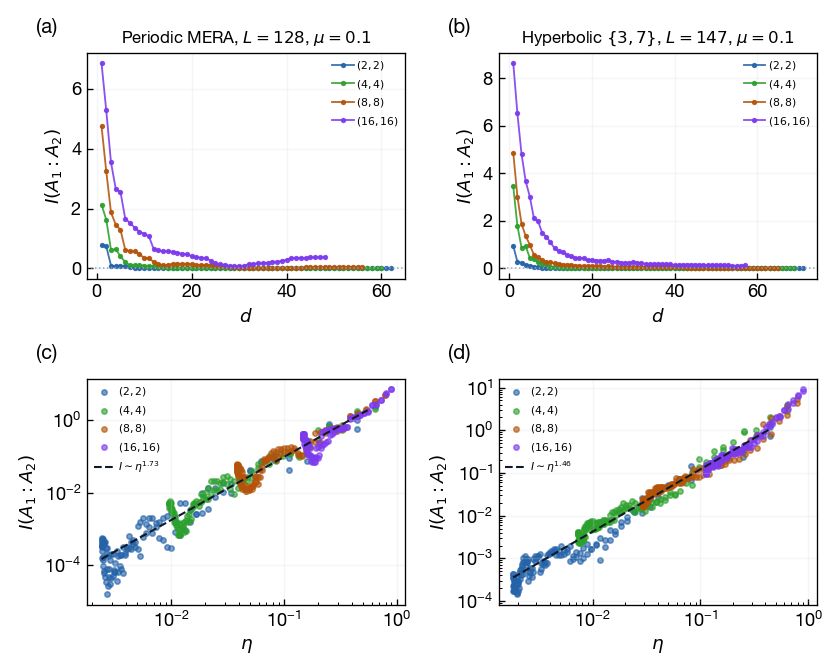

In [5]:
bbox = Bbox.from_bounds(0, 0, 7.0, 5.6)
%config InlineBackend.print_figure_kwargs = {'bbox_inches': bbox}
fig, axes = plt.subplots(2, 2, figsize=(bbox.width, bbox.height), sharex=False)

for col, system in enumerate(systems):
    ax_sep = axes[0, col]
    ax_mi = axes[1, col]
    fit = system["single_interval_fit"]

    for idx, entry in enumerate(system["series"]):
        x = np.asarray(entry["geometry"]["cross_ratio"], dtype=float)
        mask = np.asarray(entry["mask"], dtype=bool)
        mi = np.asarray(entry["mutual_information"], dtype=float)
        gaps = np.asarray(entry["gaps"], dtype=float)
        wrap_gap = np.asarray(entry["geometry"]["wrap_gap"], dtype=float)
        separation = np.minimum(gaps, wrap_gap)
        valid_mi = mask & np.isfinite(mi) & (mi > 0.0)
        valid_sep = mask & np.isfinite(mi) & np.isfinite(separation)
        color = PAIR_COLORS[idx % len(PAIR_COLORS)]
        pair_label = rf"$({entry['l1']},{entry['l2']})$"

        sep_valid = separation[valid_sep].astype(int)
        mi_valid_sep = mi[valid_sep]
        sep_unique = np.asarray(sorted(set(sep_valid)), dtype=int)
        mi_by_sep = np.asarray([np.mean(mi_valid_sep[sep_valid == value]) for value in sep_unique], dtype=float)
        ax_sep.plot(
            sep_unique,
            mi_by_sep,
            color=color,
            lw=1.1,
            alpha=0.88,
            marker="o",
            ms=2.2,
            label=pair_label,
        )

        order_mi = np.argsort(x[valid_mi])
        ax_mi.scatter(
            x[valid_mi][order_mi],
            mi[valid_mi][order_mi],
            s=10,
            color=color,
            alpha=0.62,
            label=pair_label,
        )

    small_fit = system["small_x_fit"]
    if small_fit["num_points"] >= small_x_fit_min_points:
        ax_mi.plot(
            small_fit["x_fit"],
            small_fit["i_fit"],
            color=COLORS["fit"],
            lw=1.25,
            ls="--",
            label=rf"$I\sim \eta^{{{small_fit['slope_p']:.2f}}}$",
        )

    ax_sep.axhline(0.0, color="#94a3b8", lw=0.9, ls=":")
    ax_sep.set_title(rf"{system['label']}, $L={fit['boundary_length']}$, $\mu={float(system['config'].presqueeze):.2g}$", fontsize=10)
    ax_sep.set_xlabel(r"$d$")
    ax_sep.set_ylabel(r"$I(A_1:A_2)$")
    ax_sep.grid(alpha=0.22, color=COLORS["grid"])
    ax_sep.legend(frameon=False, fontsize=6.5, ncol=1, handletextpad=0.25, borderaxespad=0.2)

    ax_mi.set_xscale("log")
    ax_mi.set_yscale("log")
    ax_mi.set_xlabel(r"$\eta$")
    ax_mi.set_ylabel(r"$I(A_1:A_2)$")
    ax_mi.grid(alpha=0.22, color=COLORS["grid"])
    ax_mi.legend(frameon=False, fontsize=6.5, ncol=1, handletextpad=0.25, borderaxespad=0.2)

labels = ["(a)", "(b)", "(c)", "(d)"]
for label, ax in zip(labels, axes.ravel()):
    ax.text(-0.16, 1.09, label, transform=ax.transAxes, fontsize=subfigure_label_fontsize)

fig.tight_layout(pad=1.0)
save_figure_with_hash(fig, FIGURE_PATH)
plt.show()


